<a href="https://colab.research.google.com/github/ligimathew123/Retail-Demand-Forecasting-Inventory-Optimization/blob/main/notebooks/retail_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles/folders here:")
print(os.listdir())

Current folder:
c:\Users\buddh\Retail-Demand-Forecasting-Inventory-Optimization\notebooks

Files/folders here:
['retail_forecasting.ipynb']


In [9]:
import zipfile

sales_zip = r"..\data\raw\data\raw\sales_train_evaluation.csv.zip"
prices_zip = r"..\data\raw\data\raw\sell_prices.csv.zip"

with zipfile.ZipFile(sales_zip, "r") as zip_ref:
    zip_ref.extractall(r"..\data\raw\data\raw")

with zipfile.ZipFile(prices_zip, "r") as zip_ref:
    zip_ref.extractall(r"..\data\raw\data\raw")

print("ZIP files extracted successfully.")

ZIP files extracted successfully.


In [11]:
sales = pd.read_csv(r"..\data\raw\data\raw\sales_train_evaluation.csv")
prices = pd.read_csv(r"..\data\raw\data\raw\sell_prices.csv")
calendar = pd.read_csv(r"..\data\raw\data\raw\calendar.csv")

print("Sales shape:", sales.shape)
print("Prices shape:", prices.shape)
print("Calendar shape:", calendar.shape)

Sales shape: (30490, 1947)
Prices shape: (6841121, 4)
Calendar shape: (1969, 14)


In [12]:
print("Sales:")
display(sales.head())
print(sales.info())

print("\nPrices:")
display(prices.head())
print(prices.info())

print("\nCalendar:")
display(calendar.head())
print(calendar.info())

Sales:


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


<class 'pandas.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1947 entries, id to d_1941
dtypes: int64(1941), str(6)
memory usage: 454.7 MB
None

Prices:


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


<class 'pandas.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   store_id    str    
 1   item_id     str    
 2   wm_yr_wk    int64  
 3   sell_price  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 318.1 MB
None

Calendar:


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


<class 'pandas.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   date          1969 non-null   str  
 1   wm_yr_wk      1969 non-null   int64
 2   weekday       1969 non-null   str  
 3   wday          1969 non-null   int64
 4   month         1969 non-null   int64
 5   year          1969 non-null   int64
 6   d             1969 non-null   str  
 7   event_name_1  162 non-null    str  
 8   event_type_1  162 non-null    str  
 9   event_name_2  5 non-null      str  
 10  event_type_2  5 non-null      str  
 11  snap_CA       1969 non-null   int64
 12  snap_TX       1969 non-null   int64
 13  snap_WI       1969 non-null   int64
dtypes: int64(7), str(7)
memory usage: 263.1 KB
None


In [13]:
print("Sales missing values:", sales.isnull().sum().sum())
print("Prices missing values:", prices.isnull().sum().sum())
print("Calendar missing values:", calendar.isnull().sum().sum())

Sales missing values: 0
Prices missing values: 0
Calendar missing values: 7542


In [14]:
calendar.isnull().sum()

date               0
wm_yr_wk           0
weekday            0
wday               0
month              0
year               0
d                  0
event_name_1    1807
event_type_1    1807
event_name_2    1964
event_type_2    1964
snap_CA            0
snap_TX            0
snap_WI            0
dtype: int64

In [15]:
print(calendar.columns.tolist())

['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI']


In [16]:
display(calendar.head(10))

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1
5,2011-02-03,11101,Thursday,6,2,2011,d_6,NaN,NaN,NaN,NaN,1,1,1
6,2011-02-04,11101,Friday,7,2,2011,d_7,NaN,NaN,NaN,NaN,1,0,0
7,2011-02-05,11102,Saturday,1,2,2011,d_8,NaN,NaN,NaN,NaN,1,1,1
8,2011-02-06,11102,Sunday,2,2,2011,d_9,SuperBowl,Sporting,NaN,NaN,1,1,1
9,2011-02-07,11102,Monday,3,2,2011,d_10,NaN,NaN,NaN,NaN,1,1,0


In [17]:
event_columns = [
    'event_name_1',
    'event_type_1',
    'event_name_2',
    'event_type_2'
]

calendar[event_columns] = calendar[event_columns].fillna('None')

In [18]:
calendar[event_columns].isnull().sum()

event_name_1    0
event_type_1    0
event_name_2    0
event_type_2    0
dtype: int64

In [19]:
calendar.dtypes

date              str
wm_yr_wk        int64
weekday           str
wday            int64
month           int64
year            int64
d                 str
event_name_1      str
event_type_1      str
event_name_2      str
event_type_2      str
snap_CA         int64
snap_TX         int64
snap_WI         int64
dtype: object

In [20]:
prices.dtypes

store_id          str
item_id           str
wm_yr_wk        int64
sell_price    float64
dtype: object

In [21]:
sales.dtypes

id            str
item_id       str
dept_id       str
cat_id        str
store_id      str
            ...  
d_1937      int64
d_1938      int64
d_1939      int64
d_1940      int64
d_1941      int64
Length: 1947, dtype: object

In [22]:
display(sales.head())

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [23]:
display(
    sales[['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']].head()
)

,id,item_id,dept_id,cat_id,store_id,state_id
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA


EDA

In [24]:
print("Unique items:", sales['item_id'].nunique())
print("Unique departments:", sales['dept_id'].nunique())
print("Unique categories:", sales['cat_id'].nunique())
print("Unique stores:", sales['store_id'].nunique())
print("Unique states:", sales['state_id'].nunique())

Unique items: 3049
Unique departments: 7
Unique categories: 3
Unique stores: 10
Unique states: 3


In [25]:
print("Categories:")
print(sales['cat_id'].unique())

print("\nDepartments:")
print(sales['dept_id'].unique())

print("\nStores:")
print(sales['store_id'].unique())

print("\nStates:")
print(sales['state_id'].unique())

Categories:
<ArrowStringArray>
['HOBBIES', 'HOUSEHOLD', 'FOODS']
Length: 3, dtype: str

Departments:
<ArrowStringArray>
[  'HOBBIES_1',   'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2',     'FOODS_1',
     'FOODS_2',     'FOODS_3']
Length: 7, dtype: str

Stores:
<ArrowStringArray>
['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2',
 'WI_3']
Length: 10, dtype: str

States:
<ArrowStringArray>
['CA', 'TX', 'WI']
Length: 3, dtype: str


In [26]:
sales_columns = [col for col in sales.columns if col.startswith('d_')]

print("Number of daily sales columns:", len(sales_columns))

Number of daily sales columns: 1941


In [27]:
total_sales = sales[sales_columns].sum().sum()

print("Total sales:", total_sales)

Total sales: 66927173


In [28]:
sales['total_sales'] = sales[sales_columns].sum(axis=1)

top_items = (
    sales[['id', 'item_id', 'dept_id', 'cat_id',
           'store_id', 'state_id', 'total_sales']]
    .sort_values('total_sales', ascending=False)
    .head(10)
)

display(top_items)

C:\Users\buddh\AppData\Local\Temp\ipykernel_12712\813233561.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sales['total_sales'] = sales[sales_columns].sum(axis=1)


,id,item_id,dept_id,cat_id,store_id,state_id,total_sales
8412,FOODS_3_090_CA_3_evaluation,FOODS_3_090,FOODS_3,FOODS,CA_3,CA,253859
18055,FOODS_3_586_TX_2_evaluation,FOODS_3_586,FOODS_3,FOODS,TX_2,TX,195120
21104,FOODS_3_586_TX_3_evaluation,FOODS_3_586,FOODS_3,FOODS,TX_3,TX,151862
8908,FOODS_3_586_CA_3_evaluation,FOODS_3_586,FOODS_3,FOODS,CA_3,CA,136269
2314,FOODS_3_090_CA_1_evaluation,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,128855
29755,FOODS_3_090_WI_3_evaluation,FOODS_3_090,FOODS_3,FOODS,WI_3,WI,123500
17559,FOODS_3_090_TX_2_evaluation,FOODS_3_090,FOODS_3,FOODS,TX_2,TX,121275
20608,FOODS_3_090_TX_3_evaluation,FOODS_3_090,FOODS_3,FOODS,TX_3,TX,116773
17721,FOODS_3_252_TX_2_evaluation,FOODS_3_252,FOODS_3,FOODS,TX_2,TX,115613
15006,FOODS_3_586_TX_1_evaluation,FOODS_3_586,FOODS_3,FOODS,TX_1,TX,114010


In [29]:
print("Categories:")
print(sales['cat_id'].unique())

print("\nDepartments:")
print(sales['dept_id'].unique())

print("\nStores:")
print(sales['store_id'].unique())

print("\nStates:")
print(sales['state_id'].unique())

Categories:
<ArrowStringArray>
['HOBBIES', 'HOUSEHOLD', 'FOODS']
Length: 3, dtype: str

Departments:
<ArrowStringArray>
[  'HOBBIES_1',   'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2',     'FOODS_1',
     'FOODS_2',     'FOODS_3']
Length: 7, dtype: str

Stores:
<ArrowStringArray>
['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2',
 'WI_3']
Length: 10, dtype: str

States:
<ArrowStringArray>
['CA', 'TX', 'WI']
Length: 3, dtype: str


In [30]:
sales_columns = [col for col in sales.columns if col.startswith('d_')]

print("Number of daily sales columns:", len(sales_columns))

total_sales = sales[sales_columns].sum().sum()

print("Total sales:", total_sales)

Number of daily sales columns: 1941
Total sales: 66927173


In [31]:
#Find the top 10 selling products
sales['total_sales'] = sales[sales_columns].sum(axis=1)

top_items = (
    sales[['id', 'item_id', 'dept_id', 'cat_id',
           'store_id', 'state_id', 'total_sales']]
    .sort_values('total_sales', ascending=False)
    .head(10)
)

display(top_items)

,id,item_id,dept_id,cat_id,store_id,state_id,total_sales
8412,FOODS_3_090_CA_3_evaluation,FOODS_3_090,FOODS_3,FOODS,CA_3,CA,253859
18055,FOODS_3_586_TX_2_evaluation,FOODS_3_586,FOODS_3,FOODS,TX_2,TX,195120
21104,FOODS_3_586_TX_3_evaluation,FOODS_3_586,FOODS_3,FOODS,TX_3,TX,151862
8908,FOODS_3_586_CA_3_evaluation,FOODS_3_586,FOODS_3,FOODS,CA_3,CA,136269
2314,FOODS_3_090_CA_1_evaluation,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,128855
29755,FOODS_3_090_WI_3_evaluation,FOODS_3_090,FOODS_3,FOODS,WI_3,WI,123500
17559,FOODS_3_090_TX_2_evaluation,FOODS_3_090,FOODS_3,FOODS,TX_2,TX,121275
20608,FOODS_3_090_TX_3_evaluation,FOODS_3_090,FOODS_3,FOODS,TX_3,TX,116773
17721,FOODS_3_252_TX_2_evaluation,FOODS_3_252,FOODS_3,FOODS,TX_2,TX,115613
15006,FOODS_3_586_TX_1_evaluation,FOODS_3_586,FOODS_3,FOODS,TX_1,TX,114010


Visualization


In [32]:
category_sales = (
    sales.groupby('cat_id')['total_sales']
    .sum()
    .sort_values(ascending=False)
)

display(category_sales)

cat_id
FOODS        45922427
HOUSEHOLD    14764090
HOBBIES       6240656
Name: total_sales, dtype: int64

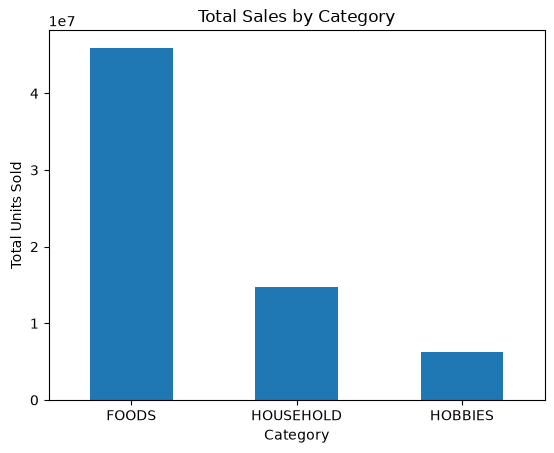

In [33]:
import matplotlib.pyplot as plt

category_sales.plot(kind='bar')

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=0)
plt.show()

**Finding:**

Sales were analyzed across the three major categories: FOODS, HOBBIES, and HOUSEHOLD.
The category-level comparison helps identify which product category contributes the most to overall demand.
Category information can be used as an important feature in the forecasting model.

In [34]:
store_sales = (
    sales.groupby('store_id')['total_sales']
    .sum()
    .sort_values(ascending=False)
)

display(store_sales)

store_id
CA_3    11363540
CA_1     7832248
TX_2     7329642
WI_2     6697988
WI_3     6542557
TX_3     6205940
CA_2     5818395
TX_1     5692823
WI_1     5261506
CA_4     4182534
Name: total_sales, dtype: int64

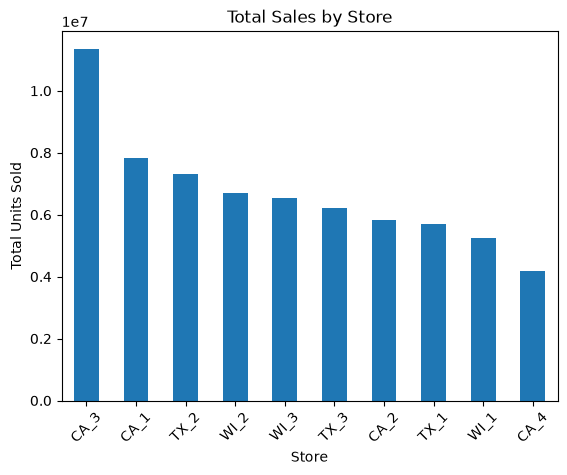

In [35]:
store_sales.plot(kind='bar')

plt.title('Total Sales by Store')
plt.xlabel('Store')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=45)
plt.show()

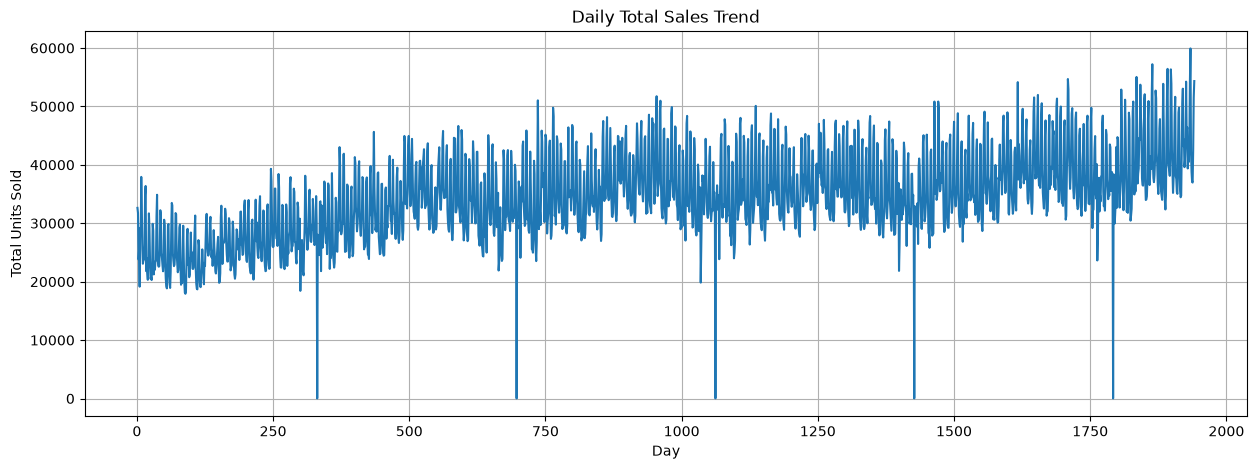

In [36]:
daily_sales = sales[sales_columns].sum(axis=0)

daily_sales.index = range(1, len(daily_sales) + 1)

plt.figure(figsize=(15, 5))
plt.plot(daily_sales)

plt.title('Daily Total Sales Trend')
plt.xlabel('Day')
plt.ylabel('Total Units Sold')
plt.grid(True)
plt.show()

In [41]:
import os

data_path = r"..\data\raw\data\raw"

print(os.listdir(data_path))

['.gitkeep', 'calendar.csv', 'sales_train_evaluation.csv', 'sales_train_evaluation.csv.zip', 'sell_prices.csv', 'sell_prices.csv.zip']


In [42]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles in current folder:")
print(os.listdir())

Current folder:
c:\Users\buddh\Retail-Demand-Forecasting-Inventory-Optimization\notebooks

Files in current folder:
['retail_forecasting.ipynb']


In [45]:
print(os.listdir('/content'))

FileNotFoundError: [WinError 3] The system cannot find the path specified: '/content'

In [46]:
import pandas as pd

sales = pd.read_csv(
    r"..\data\raw\data\raw\sales_train_evaluation.csv"
)

prices = pd.read_csv(
    r"..\data\raw\data\raw\sell_prices.csv"
)

calendar = pd.read_csv(
    r"..\data\raw\data\raw\calendar.csv"
)

print("Sales shape:", sales.shape)
print("Prices shape:", prices.shape)
print("Calendar shape:", calendar.shape)

Sales shape: (30490, 1947)
Prices shape: (6841121, 4)
Calendar shape: (1969, 14)


In [48]:
import pandas as pd
import matplotlib.pyplot as plt

sales_df = pd.read_csv(
    r"..\data\raw\data\raw\sales_train_evaluation.csv"
)
print(sales_df.shape)
sales_df.head()

(30490, 1947)


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [49]:
days = [col for col in sales_df.columns if col.startswith('d_')]

print("Number of daily columns:", len(days))
print(days[:5])

Number of daily columns: 1941
['d_1', 'd_2', 'd_3', 'd_4', 'd_5']


In [50]:
daily_sales = sales_df[days].sum()

daily_sales.index = range(1, len(daily_sales) + 1)

print(daily_sales.head())

1    32631
2    31749
3    23783
4    25412
5    19146
dtype: int64


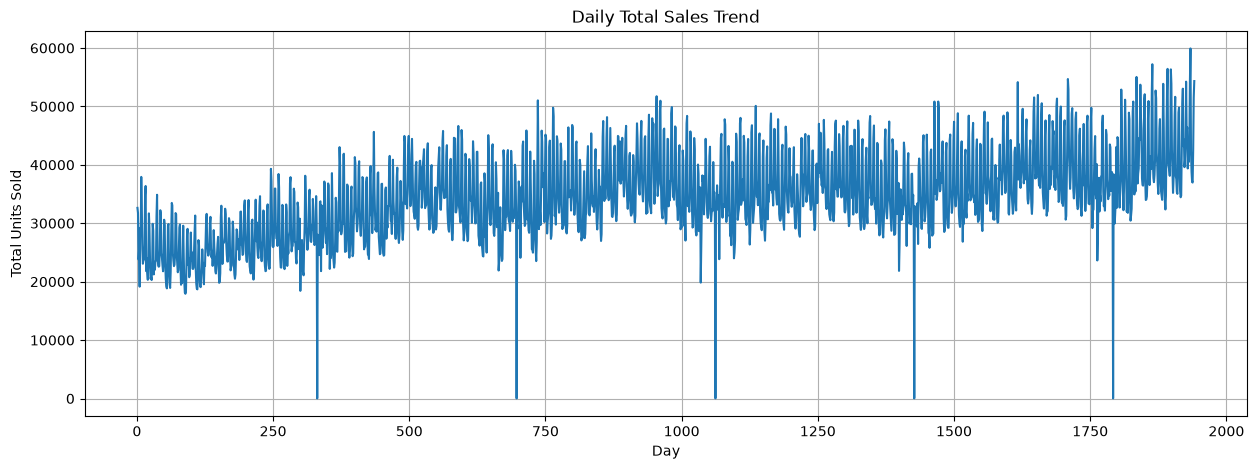

In [51]:
plt.figure(figsize=(15, 5))

plt.plot(daily_sales)

plt.title('Daily Total Sales Trend')

plt.xlabel('Day')

plt.ylabel('Total Units Sold')

plt.grid(True)

plt.show()

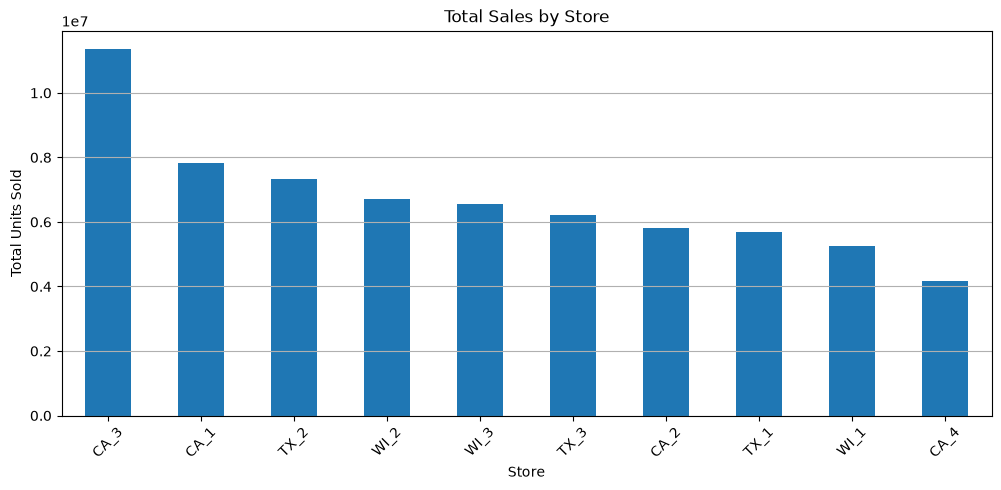

In [52]:
#Total sales by store

store_sales = sales_df.groupby('store_id')[days].sum().sum(axis=1)

store_sales = store_sales.sort_values(ascending=False)

plt.figure(figsize=(12, 5))

store_sales.plot(kind='bar')

plt.title('Total Sales by Store')
plt.xlabel('Store')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=45)

plt.grid(axis='y')
plt.show()

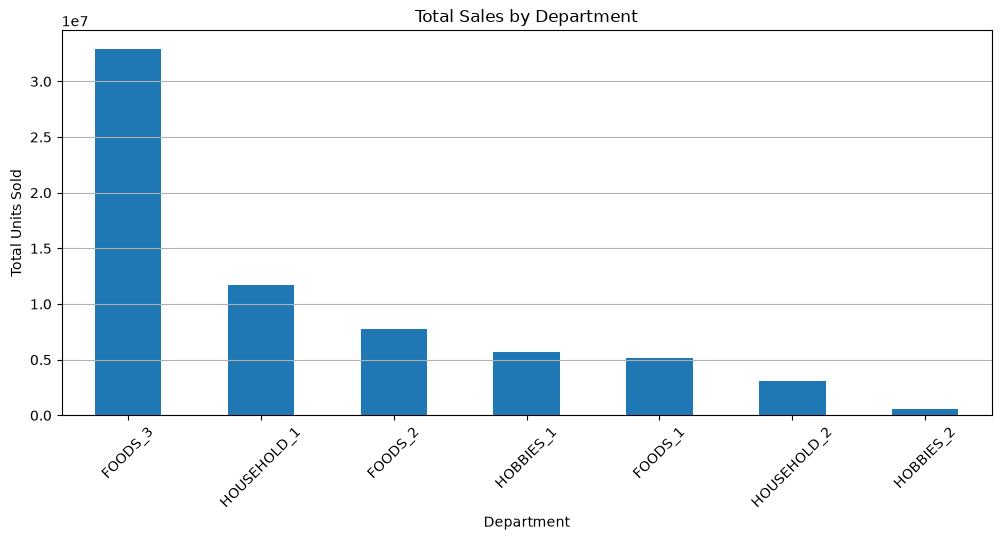

In [53]:
#Sales by Department
dept_sales = sales_df.groupby('dept_id')[days].sum().sum(axis=1)

dept_sales = dept_sales.sort_values(ascending=False)

plt.figure(figsize=(12, 5))

dept_sales.plot(kind='bar')

plt.title('Total Sales by Department')
plt.xlabel('Department')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=45)

plt.grid(axis='y')
plt.show()

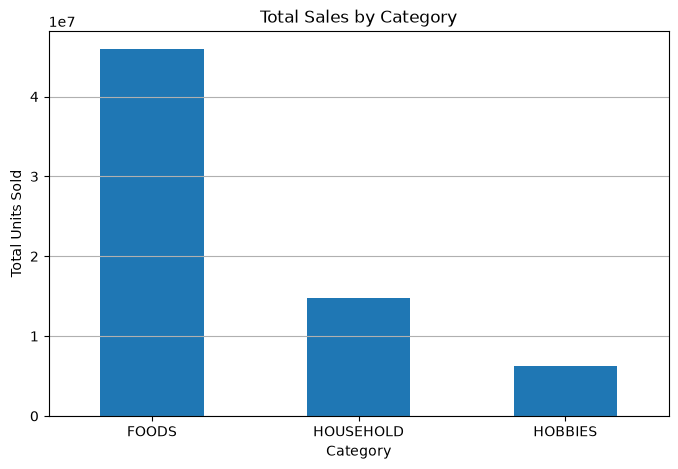

In [54]:
#Sales by Category
category_sales = sales_df.groupby('cat_id')[days].sum().sum(axis=1)

category_sales = category_sales.sort_values(ascending=False)

plt.figure(figsize=(8, 5))

category_sales.plot(kind='bar')

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=0)

plt.grid(axis='y')
plt.show()

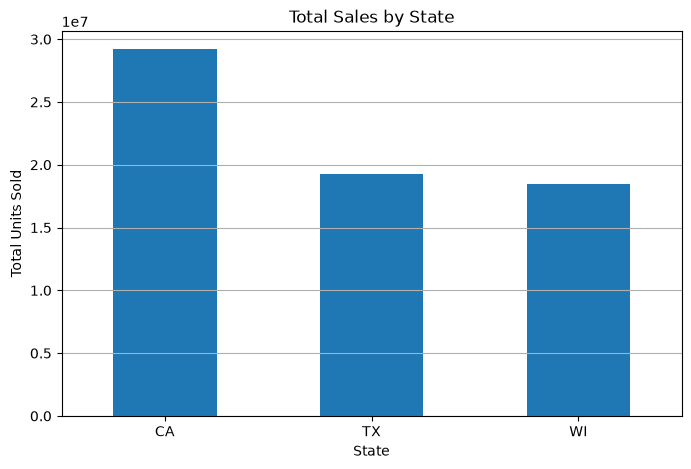

In [55]:
#Sales by State

state_sales = sales_df.groupby('state_id')[days].sum().sum(axis=1)

state_sales = state_sales.sort_values(ascending=False)

plt.figure(figsize=(8, 5))

state_sales.plot(kind='bar')

plt.title('Total Sales by State')
plt.xlabel('State')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=0)

plt.grid(axis='y')
plt.show()

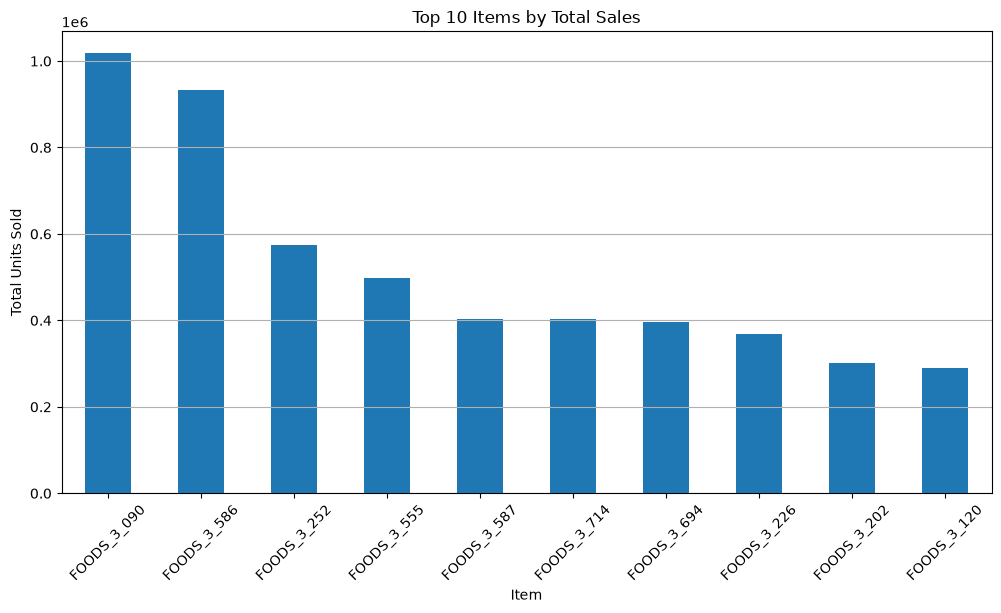

In [56]:
#Top 10 Items by Sales

item_sales = sales_df.groupby('item_id')[days].sum().sum(axis=1)

top_10_items = item_sales.sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))

top_10_items.plot(kind='bar')

plt.title('Top 10 Items by Total Sales')
plt.xlabel('Item')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=45)

plt.grid(axis='y')
plt.show()

In [58]:
#Analyze sales by day of week

import pandas as pd

calendar_df = pd.read_csv(
    r"..\data\raw\data\raw\calendar.csv"
)

print(calendar_df.shape)
calendar_df.head()

(1969, 14)


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [59]:
#Average Sales by Day of Week
# Create a dataframe combining daily sales and calendar information

daily_sales_df = pd.DataFrame({
    'd': [f'd_{i}' for i in range(1, len(daily_sales) + 1)],
    'sales': daily_sales.values
})

daily_sales_df = daily_sales_df.merge(
    calendar_df[['d', 'weekday']],
    on='d',
    how='left'
)

daily_sales_df.head()

,d,sales,weekday
0,d_1,32631,Saturday
1,d_2,31749,Sunday
2,d_3,23783,Monday
3,d_4,25412,Tuesday
4,d_5,19146,Wednesday


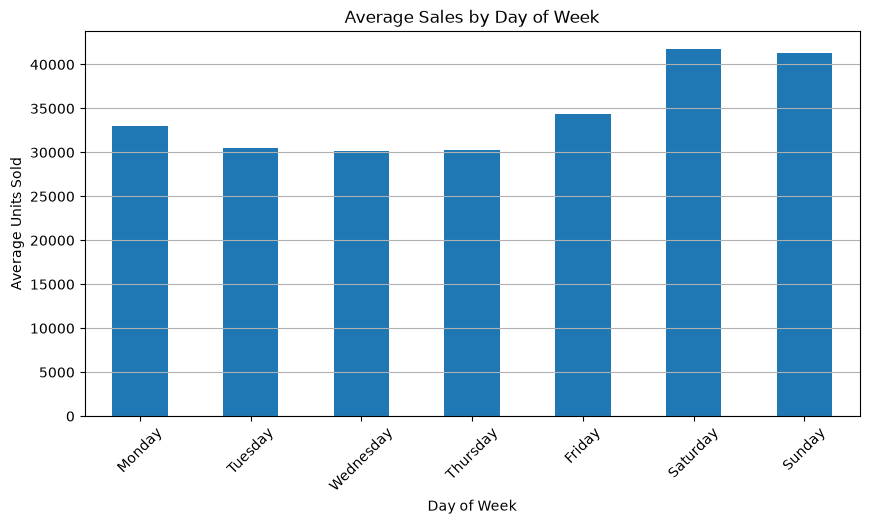

In [60]:
weekday_sales = daily_sales_df.groupby('weekday')['sales'].mean()

weekday_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

weekday_sales = weekday_sales.reindex(weekday_order)

plt.figure(figsize=(10, 5))

weekday_sales.plot(kind='bar')

plt.title('Average Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Units Sold')
plt.xticks(rotation=45)

plt.grid(axis='y')
plt.show()

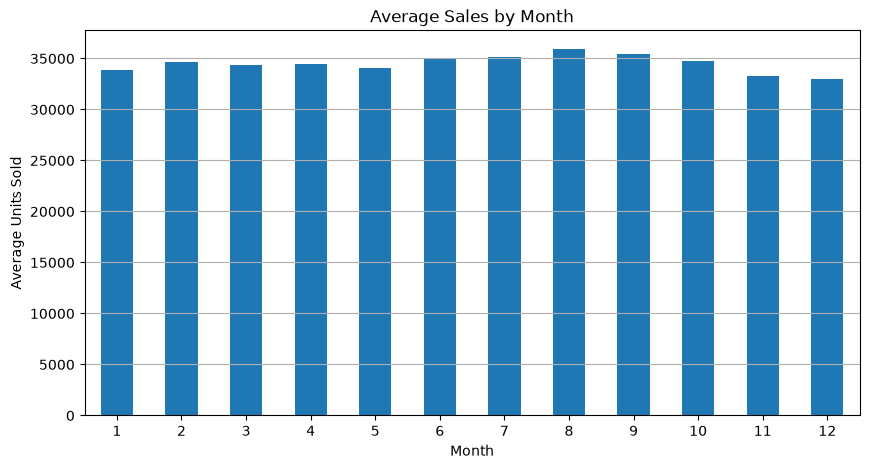

In [61]:
#Monthly Sales Trend

daily_sales_df['month'] = daily_sales_df['d'].map(
    calendar_df.set_index('d')['month']
)

monthly_sales = daily_sales_df.groupby('month')['sales'].mean()

plt.figure(figsize=(10, 5))

monthly_sales.plot(kind='bar')

plt.title('Average Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Units Sold')
plt.xticks(rotation=0)

plt.grid(axis='y')
plt.show()

In [62]:
#Event/Holiday Impact
daily_sales_df = daily_sales_df.merge(
    calendar_df[['d', 'event_name_1']],
    on='d',
    how='left',
    suffixes=('', '_calendar')
)

daily_sales_df['event_day'] = daily_sales_df['event_name_1'].notna()

event_sales = daily_sales_df.groupby('event_day')['sales'].mean()

print(event_sales)

event_day
False    34609.336511
True     33029.911392
Name: sales, dtype: float64


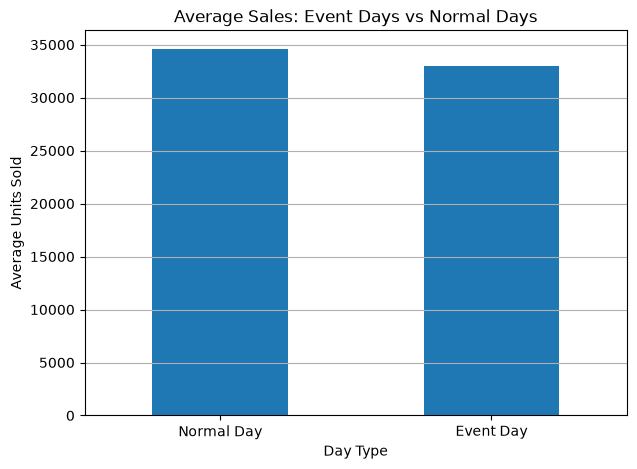

In [63]:
plt.figure(figsize=(7, 5))

event_sales.plot(kind='bar')

plt.title('Average Sales: Event Days vs Normal Days')
plt.xlabel('Day Type')
plt.ylabel('Average Units Sold')
plt.xticks(
    ticks=[0, 1],
    labels=['Normal Day', 'Event Day'],
    rotation=0
)

plt.grid(axis='y')
plt.show()

| Analysis                   | Finding                |
| -------------------------- | ---------------------- |
| Daily sales trend          | Trend analyzed         |
| Highest-selling store      | **CA_3**               |
| Highest-selling department | **FOODS**              |
| Highest-selling category   | **FOODS**              |
| Highest-selling state      | **CA**                 |
| Top-selling item           | **FOODS_3_090**        |
| Highest-sales weekday      | **Saturday**           |
| Highest-sales month        | **August (8)**         |
| Event vs normal days       | **Normal days higher** |


In [1]:
from google.cloud import bigquery
import pandas as pd

client = bigquery.Client(project="retail-forecasting-506113")

query = """
SELECT
    item_id,
    store_id,
    ds,
    actual_demand,
    predicted_demand,
    model
FROM `retail-forecasting-506113.retail_forecasting.lightgbm_forecasts`
"""

lightgbm_forecasts = client.query(query).to_dataframe()

print("Forecast data loaded successfully.")
print("Rows:", len(lightgbm_forecasts))

lightgbm_forecasts.head()

c:\Users\buddh\anaconda3\Lib\site-packages\google\auth\_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
c:\Users\buddh\anaconda3\Lib\site-packages\google\cloud\bigquery\table.py:2130: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Forecast data loaded successfully.
Rows: 140


,item_id,store_id,ds,actual_demand,predicted_demand,model
0,FOODS_3_090,CA_1,2016-04-25,48.0,51.734801,LightGBM
1,FOODS_3_090,CA_1,2016-04-26,35.0,45.890840,LightGBM
2,FOODS_3_090,CA_1,2016-04-27,34.0,48.650322,LightGBM
3,FOODS_3_090,CA_1,2016-04-28,67.0,47.935335,LightGBM
4,FOODS_3_090,CA_1,2016-04-29,63.0,64.243745,LightGBM


In [2]:
# ==========================================
# INVENTORY OPTIMIZATION
# ==========================================

import pandas as pd
import numpy as np

LEAD_TIME_DAYS = 7
SERVICE_LEVEL_Z = 1.645

inventory_df = lightgbm_forecasts.copy()

inventory_df["predicted_demand"] = pd.to_numeric(
    inventory_df["predicted_demand"],
    errors="coerce"
)

inventory_summary = (
    inventory_df
    .groupby(["item_id", "store_id"])
    .agg(
        average_daily_demand=("predicted_demand", "mean"),
        demand_std=("predicted_demand", "std"),
        forecast_days=("predicted_demand", "count")
    )
    .reset_index()
)

inventory_summary["demand_std"] = (
    inventory_summary["demand_std"].fillna(0)
)

inventory_summary["safety_stock"] = (
    SERVICE_LEVEL_Z
    * inventory_summary["demand_std"]
    * np.sqrt(LEAD_TIME_DAYS)
)

inventory_summary["reorder_point"] = (
    inventory_summary["average_daily_demand"]
    * LEAD_TIME_DAYS
    + inventory_summary["safety_stock"]
)

inventory_summary["recommended_inventory"] = (
    inventory_summary["reorder_point"]
    + inventory_summary["safety_stock"]
)

numeric_columns = [
    "average_daily_demand",
    "demand_std",
    "safety_stock",
    "reorder_point",
    "recommended_inventory"
]

inventory_summary[numeric_columns] = (
    inventory_summary[numeric_columns].round(2)
)

print("Inventory optimization completed.")
print("Inventory recommendations:", len(inventory_summary))

inventory_summary.head(20)

Inventory optimization completed.
Inventory recommendations: 5


,item_id,store_id,average_daily_demand,demand_std,forecast_days,safety_stock,reorder_point,recommended_inventory
0,FOODS_3_090,CA_1,59.09,15.68,28,68.24,481.85,550.10
1,FOODS_3_090,CA_3,120.02,26.62,28,115.84,955.94,1071.78
2,FOODS_3_586,CA_3,66.54,10.35,28,45.05,510.82,555.87
3,FOODS_3_586,TX_2,80.35,13.27,28,57.75,620.23,677.98
4,FOODS_3_586,TX_3,60.84,10.57,28,46.01,471.92,517.94


In [3]:
# ==========================================
# UPLOAD INVENTORY OPTIMIZATION TO BIGQUERY
# ==========================================

from google.cloud import bigquery

client = bigquery.Client(project="retail-forecasting-506113")

table_id = "retail-forecasting-506113.retail_forecasting.inventory_optimization"

job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE"
)

job = client.load_table_from_dataframe(
    inventory_summary,
    table_id,
    job_config=job_config
)

job.result()

print("Inventory optimization uploaded successfully!")
print("BigQuery table:", table_id)
print("Rows uploaded:", len(inventory_summary))

c:\Users\buddh\anaconda3\Lib\site-packages\google\auth\_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


Inventory optimization uploaded successfully!
BigQuery table: retail-forecasting-506113.retail_forecasting.inventory_optimization
Rows uploaded: 5


In [4]:
# Verify inventory optimization table

check = client.query("""
SELECT *
FROM `retail-forecasting-506113.retail_forecasting.inventory_optimization`
ORDER BY recommended_inventory DESC
""").to_dataframe()

check

c:\Users\buddh\anaconda3\Lib\site-packages\google\cloud\bigquery\table.py:2130: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,item_id,store_id,average_daily_demand,demand_std,forecast_days,safety_stock,reorder_point,recommended_inventory
0,FOODS_3_090,CA_3,120.02,26.62,28,115.84,955.94,1071.78
1,FOODS_3_586,TX_2,80.35,13.27,28,57.75,620.23,677.98
2,FOODS_3_586,CA_3,66.54,10.35,28,45.05,510.82,555.87
3,FOODS_3_090,CA_1,59.09,15.68,28,68.24,481.85,550.10
4,FOODS_3_586,TX_3,60.84,10.57,28,46.01,471.92,517.94


In [5]:
check = client.query("""
SELECT *
FROM `retail-forecasting-506113.retail_forecasting.inventory_optimization`
ORDER BY recommended_inventory DESC
""").to_dataframe()

check

c:\Users\buddh\anaconda3\Lib\site-packages\google\cloud\bigquery\table.py:2130: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,item_id,store_id,average_daily_demand,demand_std,forecast_days,safety_stock,reorder_point,recommended_inventory
0,FOODS_3_090,CA_3,120.02,26.62,28,115.84,955.94,1071.78
1,FOODS_3_586,TX_2,80.35,13.27,28,57.75,620.23,677.98
2,FOODS_3_586,CA_3,66.54,10.35,28,45.05,510.82,555.87
3,FOODS_3_090,CA_1,59.09,15.68,28,68.24,481.85,550.10
4,FOODS_3_586,TX_3,60.84,10.57,28,46.01,471.92,517.94


In [6]:
# ==========================================
# PREPARE DASHBOARD DATA
# ==========================================

dashboard_data = client.query("""
SELECT
    item_id,
    store_id,
    average_daily_demand,
    demand_std,
    safety_stock,
    reorder_point,
    recommended_inventory
FROM `retail-forecasting-506113.retail_forecasting.inventory_optimization`
ORDER BY recommended_inventory DESC
""").to_dataframe()

print("Dashboard data loaded successfully!")
print("Rows:", len(dashboard_data))

dashboard_data

c:\Users\buddh\anaconda3\Lib\site-packages\google\cloud\bigquery\table.py:2130: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Dashboard data loaded successfully!
Rows: 5


,item_id,store_id,average_daily_demand,demand_std,safety_stock,reorder_point,recommended_inventory
0,FOODS_3_090,CA_3,120.02,26.62,115.84,955.94,1071.78
1,FOODS_3_586,TX_2,80.35,13.27,57.75,620.23,677.98
2,FOODS_3_586,CA_3,66.54,10.35,45.05,510.82,555.87
3,FOODS_3_090,CA_1,59.09,15.68,68.24,481.85,550.10
4,FOODS_3_586,TX_3,60.84,10.57,46.01,471.92,517.94
